## Importing Needed Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers


## Data extraction and loading

In [2]:
base_dir = r"C:\Users\user\python-class\pneumonia\chest_xray"
train_dir = os.path.join(base_dir,"train")
test_dir = os.path.join(base_dir,"test")
val_dir = os.path.join(base_dir,"val")



In [4]:
#printing length of each directory

print("----------Train dataset----------")
print("Number of training images: ", len(os.listdir(train_dir)))
print("Number of normal images in training set: ", len(os.listdir(os.path.join(train_dir,"NORMAL"))))
print("Number of pneumonia images in training set: ", len(os.listdir(os.path.join(train_dir, "PNEUMONIA"))))

print("----------Test dataset----------")

print("Number of testing images: ", len(os.listdir(test_dir)))
print("Number of normal images in test set: ", len(os.listdir(os.path.join(test_dir,"NORMAL"))))
print("Number of pneumonia images in test set: ", len(os.listdir(os.path.join(test_dir, "PNEUMONIA"))))

print("----------validation dataset----------")
print("Number of validation images: ", len(os.listdir(val_dir)))
print("number of normal images in validation set: ", len(os.listdir(os.path.join(val_dir,"NORMAL"))))
print("number of pneumonia images in validation set: ", len(os.listdir(os.path.join(val_dir, "PNEUMONIA"))))


----------Train dataset----------
Number of training images:  2
Number of normal images in training set:  1341
Number of pneumonia images in training set:  3875
----------Test dataset----------
Number of testing images:  2
Number of normal images in test set:  234
Number of pneumonia images in test set:  390
----------validation dataset----------
Number of validation images:  2
number of normal images in validation set:  8
number of pneumonia images in validation set:  8


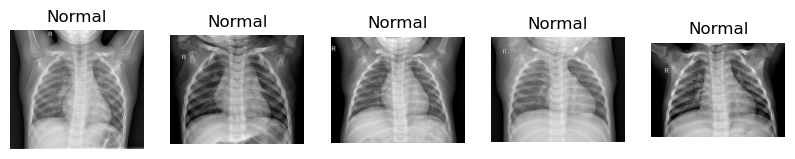

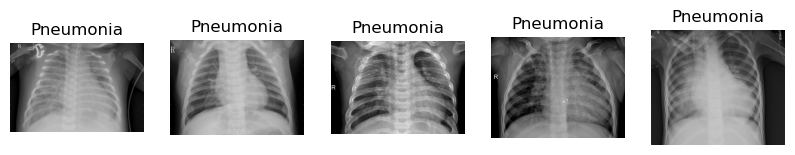

In [5]:
#printing 5 random images from training set

normal_images = os.listdir(os.path.join(train_dir,"NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_dir,"PNEUMONIA"))

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = plt.imread(os.path.join(train_dir,"NORMAL",normal_images[i]))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Normal")
plt.show()

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = plt.imread(os.path.join(train_dir,"PNEUMONIA",pneumonia_images[i]))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Pneumonia")
plt.show()

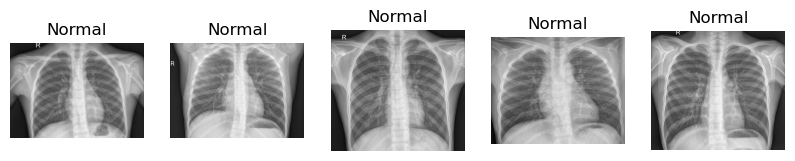

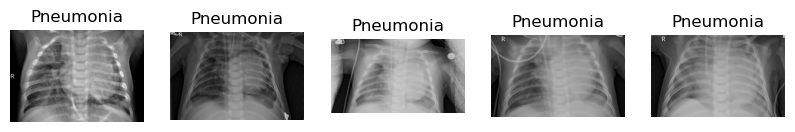

In [6]:
#printing 5 random images from test set
normal_img = os.listdir(os.path.join(test_dir,"NORMAL"))
pneumonia_img = os.listdir(os.path.join(test_dir,"PNEUMONIA"))

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = plt.imread(os.path.join(test_dir,"NORMAL",normal_img[i]))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Normal")
plt.show()

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = plt.imread(os.path.join(test_dir,"PNEUMONIA", pneumonia_img[i]))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Pneumonia")
plt.show()

In [12]:
#creating a dataframe to store the image paths and labels
data = []

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        label = folder
        data.append((file_path, label))
        df = pd.DataFrame(data, columns = ["file_path", "label"])
print(df.head())



                                           file_path   label
0  C:\Users\user\python-class\pneumonia\chest_xra...  NORMAL
1  C:\Users\user\python-class\pneumonia\chest_xra...  NORMAL
2  C:\Users\user\python-class\pneumonia\chest_xra...  NORMAL
3  C:\Users\user\python-class\pneumonia\chest_xra...  NORMAL
4  C:\Users\user\python-class\pneumonia\chest_xra...  NORMAL


In [ ]:
#checking for corrupted images in all dataset
corrupted_img=[]

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            img = plt.imread(file_path)
        except:
            corrupted_img.append(file_path)
            print("Number of corrupted images in training set: ", len(corrupted_img))
            

corrupted_img=[]
for folder in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            img = plt.imread(file_path)
        except:
            corrupted_img.append(file_path)
            print("Number of corrupted images in test set: ", len(corrupted_img))



corrupted_img=[]
for folder in os.listdir(val_dir):
    folder_path = os.path.join(val_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            img = plt.imread(file_path)
        except:
            corrupted_img.append(file_path)
            print("Number of corrupted images in test set: ", len(corrupted_img))

for img in corrupted_img:
    print(img)



In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
img_height = 224  #for transfer learning (like VGG)
img_width = 224
batch_size = 32

# Data augmentation for training
img_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
# No augmentation for validation/test, just rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data loaders
train_gen= img_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Print class mapping
print("Class indices:", train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


Dimensions of the image are: 224 pixels wide and 224 pixels high
Maximum pixel value: 1.0
Minimum pixel value: 0.0
Unique labels in the batch: [0. 1.]


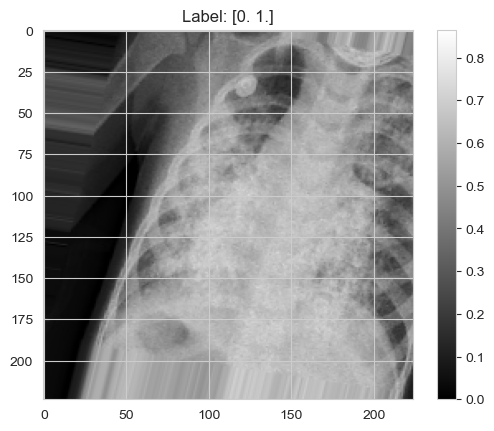

In [15]:
sns.set_style("whitegrid")
gen_img, gen_label = train_gen.__getitem__(0)
plt.imshow(gen_img[0],cmap="gray")
plt.colorbar()
plt.title("Label: {}".format(gen_label[0]))

print(f"Dimensions of the image are: {gen_img.shape[1]} pixels wide and {gen_img.shape[2]} pixels high")
print(f"Maximum pixel value: {np.max(gen_img)}")
print(f"Minimum pixel value: {np.min(gen_img)}")
print(f"Unique labels in the batch: {np.unique(gen_label)}")
